# МАТРИЦЫ ПЛАНИРОВАНИЯ ЭКСПЕРИМЕНТА
### два основных источника:
1. Новик Ф. С., Арсов Я. Б. Оптимизация процессов технологии металлов методами планирования экспериментов. М. : Машиностроение. 1980. 304 с.
2. https://github.com/relf/pyDOE3/tree/master
### Задача:
Построить наиболее распространенные матрицы планирвоания эксперимента без использования специализированных библиотек, что бы алгоритм построения был легко понятен программисту, не работающему с Python 


In [844]:
# для проверки работоспособности методов будем использоватеь библиотеку pydoe3
import pyDOE3 as doe
# плюс при построении латинского гиперкуба понадобится генерить случайное число
import random
# для решения нормального уравнения (расчета вектора неизвестных коэффициентов уравнений регрессии) нам все-таки понядобится библиотека NumPy
import numpy as np
# в какой-то момент понадобится логорифм, поэтому библиотеку math все-таки придется импортировать
import math
# метрики для проверки моделей
from sklearn.metrics import r2_score
# matplotlib для построения графика паритета
import matplotlib.pyplot as plt


# Все рассматриваемые ниже матрицы планирования кодируются таким образом, что:
- низкий уровень → -1 (наименьшее из возможных значений параметра варьирования) 
- высокий уровень → +1 (наибольшее из возможных значений параметра варьирования)

 **Общий вид кодирования фактора:**
$$
x_j = \frac{X_j - X_{j0}}{\Delta_j}
$$
где:
- $ x_j $ — кодированное значение фактора (безразмерное, $ -1 $ или $ +1 $)
- $ X_j $ — натуральное значение фактора
- $ X_{j0} = \frac{X_{j\text{max}} + X_{j\text{min}}}{2} $ — **центр уровня** (середина интервала)
- $ \Delta_j = \frac{X_{j\text{max}} - X_{j\text{min}}}{2} $ — **интервал варьирования**

# Две функции для пересчета переменной из натурального в кодированный масштаб и обратно:

In [845]:
# Функця для персчета натурального масштаба в кодированный
def natural_to_coded(x_natural, x_min, x_max, scale='centered'):
    """
    Преобразует значение фактора из натурального масштаба в кодированный.
    
    Параметры:
        x_natural (float или array-like): значение(я) в натуральном масштабе
        x_min (float): минимальное значение фактора
        x_max (float): максимальное значение фактора
        scale (str): тип кодирования:
            - 'centered' (по умолчанию): диапазон [-1, +1]
            - 'unit': диапазон [0, +1]
    
    Возвращает:
        float или ndarray: значение(я) в кодированном масштабе
    """
    if x_min >= x_max:
        raise ValueError("x_min должно быть строго меньше x_max")
    
    if scale == 'centered':
        x_center = (x_min + x_max) / 2.0
        delta_x = (x_max - x_min) / 2.0
        return (x_natural - x_center) / delta_x
    
    elif scale == 'unit':
        return (x_natural - x_min) / (x_max - x_min)
    
    else:
        raise ValueError("Параметр 'scale' должен быть 'centered' или 'unit'")

# Функця для персчета кодированного масштаба в натуральный
def coded_to_natural(x_coded, x_min, x_max, scale='centered'):
    """
    Преобразует значение фактора из кодированного масштаба в натуральный.
    
    Параметры:
        x_coded (float или array-like): значение(я) в кодированном масштабе
        x_min (float): минимальное значение фактора в натуральном масштабе
        x_max (float): максимальное значение фактора в натуральном масштабе
        scale (str): тип кодирования, использованный при прямом преобразовании:
            - 'centered' (по умолчанию): диапазон [-1, +1]
            - 'unit': диапазон [0, +1]
    
    Возвращает:
        float или ndarray: значение(я) в натуральном масштабе
    """
    if x_min >= x_max:
        raise ValueError("x_min должно быть строго меньше x_max")
    
    if scale == 'centered':
        x_center = (x_min + x_max) / 2.0
        delta_x = (x_max - x_min) / 2.0
        return x_center + x_coded * delta_x
    
    elif scale == 'unit':
        return x_min + x_coded * (x_max - x_min)
    
    else:
        raise ValueError("Параметр 'scale' должен быть 'centered' или 'unit'")

# Четыре вспомогательные функции:
- функция для генерации искусственного датасета (не используется, но пусть будет)
- Функция для расчета коэффициента детерминачии
- Функция для расчета среднеквадратичной ошибки
- Функция для построения графика паритета

In [846]:
# функция для искуственной генерации данных
#def function_5d (x1, x2, x3, x4, x5):
 #   function = x1**2 + 2*x2**2 + 3*x3**3 + 4*x4**2 + 5*x5**1 + 1
  #  return function


def function_5d(x1, x2, x3, x4, x5):
    # Приводим всё к массивам — на случай, если переданы скаляры
    x1, x2, x3, x4, x5 = map(np.asarray, (x1, x2, x3, x4, x5))


    # Определяем количество точек
    # Для скаляра — 1, для массива — len
    n = max(x.size for x in (x1, x2, x3, x4, x5))
    
    # Линейная часть — работает поэлементно благодаря NumPy broadcasting
    linear = 2*x1 + 3*x2 - x3 + 2*x5    
    # Сумма квадратов: x1^2 + x2^2 + ... + x5^2 (поэлементно)
    sum_of_cubes = x1**3 + x3**3 + x4**3 + x5**3
    
    # Нелинейная добавка
    nonlinear = 0.5 * np.exp(-0.5 * sum_of_cubes)

    
    y_clean = linear + nonlinear
    
    # Генерируем повторяемый шум: фиксируем seed = n (или другое число)
    rng = np.random.default_rng(seed=1488+n)  
    noise_multiplier = rng.uniform(0.9, 1.1, size=n)
    
    # Если исходные данные — скаляр, вернём скаляр
    if n == 1:
        return float(y_clean * noise_multiplier[0])
    else:
        return y_clean * noise_multiplier



# функця для расчета коэффициента детерминации

def r_2(y_true, y_pred):
    """
    Вычисляет коэффициент детерминации R^2.
    
    Параметры:
        y_true (array-like): истинные значения целевой переменной.
        y_pred (array-like): предсказанные моделью значения.
        
    Возвращает:
        float: значение R^2.
        
    Примечание:
        Формула: R^2 = 1 - SS_res / SS_tot,
        где SS_res = sum((y_true - y_pred)^2),
             SS_tot = sum((y_true - mean(y_true))^2).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true и y_pred должны иметь одинаковую форму")
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    if ss_tot == 0:
        # Если все y_true одинаковы, R^2 не определён; по соглашению возвращаем 1.0,
        # если модель тоже предсказывает это значение, иначе — отрицательное число.
        return 1.0 if ss_res == 0 else -np.inf
    
    return 1.0 - (ss_res / ss_tot)



def rmse(y_true, y_pred):
    """
    Вычисляет корень из среднеквадратичной ошибки (RMSE).
    
    Параметры:
        y_true (array-like): истинные значения целевой переменной.
        y_pred (array-like): предсказанные моделью значения.
        
    Возвращает:
        float: значение RMSE.
        
    Примечание:
        Формула: RMSE = sqrt(mean((y_true - y_pred)^2)).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true и y_pred должны иметь одинаковую форму")
    
    mse = np.mean((y_true - y_pred) ** 2)
    return float(np.sqrt(mse))


# Функция для сравнения тестовых и предсказанных значений
def plot_true_vs_predicted(y_true, y_pred, title="True vs Predicted", figsize=(8, 6)):
    """
    Строит график истинных значений vs предсказанных.
    
    Параметры:
        y_true (array-like): Истинные значения
        y_pred (array-like): Предсказанные значения
        title (str): Заголовок графика
        figsize (tuple): Размер графика
    """
    # Вычисляем метрики
    r = np.corrcoef(y_true, y_pred)[0, 1] # коэффициент корреляции
    r2 = r_2(y_true, y_pred) # коэффициент детерминации
    rmse_ = rmse(y_true, y_pred) #  среднеквадратическая ошибка
    #mape = mean_absolute_percentage_error(y_true, y_pred) # cредняя абсолютная процентная ошибка
    # Строим график
    plt.figure(figsize=figsize)
    plt.scatter(y_true, y_pred, alpha=0.6, label='Predictions')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2, label='Ideal line')

    # Добавляем метрики на график
    metrics_text = f'R = {r:.3f}\nR² = {r2:.3f}\nRMSE = {rmse_:.3f}'
    plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1))

    # Оформление графика
    plt.title(title, fontsize=14)
    plt.xlabel('True Values', fontsize=12)
    plt.ylabel('Predicted Values', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1. Полный факторный эксперимент (далее ПФЭ)
### общие сведения здесь: https://ru.wikipedia.org/wiki/Полный_факторный_эксперимент

# 1.1. Построение плана ПФЭ

In [847]:
def full_factorial(n_factors, min_val=-1, max_val=1):
    """
    Генерирует матрицу полного факторного эксперимента (ПФЭ) с заданным числом факторов.
    Сама матрица понятно и доходчиво представлена на странице 67 Новик Ф. С., Арсов Я. Б.
    Параметры:
        n_factors (int): количество факторов.
        min_val (float): нижний уровень фактора в кодированном масштабе (по умолчанию -1).
        max_val (float): верхний уровень фактора в кодированном масштабе (по умолчанию +1).
        intercept (bool): если True — добавить столбец единиц в начало (для расчета свободного члена линейной регрессии).
    
    Возвращает:
        list of lists: матрица ПФЭ эксперимента.
    """
    if n_factors < 2:
        raise ValueError("Количество факторов не может быть меньше двух.")
    
    n_rows = 2 ** n_factors # количество экспериментов
    design = [] # список куда будем записывать значения факторов в i-м эксперименте

    for i in range(n_rows):
        row = []
        for factor in range(n_factors):
            # Количество повторений одного уровня для текущего фактора (т.е. столбца), т.е.
            # для factor = № 0 → block_size = 1 → значения меняются каждую строку
            # для factor = № 1 → block_size = 2 → значения меняются каждые две строки
            # для factor = № 2 → block_size = 4 → значения меняются каждые четыре строки
            # и т.д.
            block_size = 2 ** factor 
            # Сколько таких блоков прошло до текущей строки
            # (сколько раз номер эксперимента i делится без остатка на количество повторений)
            block_index = i // block_size 
            # Чётный блок → верхний уровень, нечётный → нижний
            level = max_val if block_index % 2 == 0 else min_val
            row.append(level)
        design.append(row)
    # переворачиваем матрицу, что бы было как в pyDOE3, немотря на то, что в Новике Арсове ее пе переворачивают
    design = design[::-1]

    return design

def full_factorial_with_interactions(n_factors, min_val=-1, max_val=1, intercept=True):
    """
    Генерирует матрицу ПФЭ с основными факторами и **парными взаимодействиями**.
    Нужно только при определении коэффициентов линейной регрессии, т.е. при планировании 
    эксперимента этот метод не понадобится.
    """
    if n_factors < 2:
        raise ValueError("Количество факторов не может быть меньше двух.")

    # Получаем базовую матрицу
    base_matrix = full_factorial(n_factors, min_val=min_val, max_val=max_val)
    
    extended_matrix = []

    for row in base_matrix:
        new_row = row[:]  # копируем основные факторы

        # Добавляем ВСЕ ПАРНЫЕ взаимодействия: x_i * x_j, где i < j
        for i in range(n_factors):
            for j in range(i + 1, n_factors):
                interaction = row[i] * row[j]
                new_row.append(interaction)

        extended_matrix.append(new_row)

    # Добавляем intercept в начало, если нужно
    if intercept:
        extended_matrix = [[max_val] + row for row in extended_matrix]
    

    return extended_matrix


def add_intercept_column(matrix):
    """
    Добавляет столбец единиц в начало каждой строки матрицы плана эксперимента.
    
    Параметры:
        design_matrix (list of lists): исходная матрица ПФЭ (или любого другого плана).
        
    Возвращает:
        list of lists: матрица с добавленным первым столбцом, заполненным единицами.
    """
    return [[1] + row for row in matrix]

full_factorial(3, min_val=-1, max_val=1)

[[-1, -1, -1],
 [1, -1, -1],
 [-1, 1, -1],
 [1, 1, -1],
 [-1, -1, 1],
 [1, -1, 1],
 [-1, 1, 1],
 [1, 1, 1]]

In [848]:
# Проверяем, что резульата совпадает с pyDOE3
doe.ff2n(3)

array([[-1., -1., -1.],
       [-1., -1.,  1.],
       [-1.,  1., -1.],
       [-1.,  1.,  1.],
       [ 1., -1., -1.],
       [ 1., -1.,  1.],
       [ 1.,  1., -1.],
       [ 1.,  1.,  1.]])

# 1.2. Построение линейной модели на основе полного факторного эксперимента 

Линейная модель может быть записана в двух формах:

**1. Аддитивная (без учёта взаимодействий):**  
$$
\hat{y} = b_0 + \sum_{i=1}^{n} b_i x_i
$$

**2. С учётом парных взаимодействий факторов:**  
$$
\hat{y} = b_0 + \sum_{i=1}^{n} b_i x_i + \sum_{i=1}^{n-1} \sum_{j=i+1}^{n} b_{ij} x_i x_j
$$

где:  
- n  — число факторов,  
- $x_i$ — кодированные значения \( i \)-го фактора,  
- $b_0$ — свободный член (оценка отклика в центре плана),  
- $b_i$ — коэффициенты при линейных эффектах,  
- $b_{ij}$ — коэффициенты при парных взаимодействиях факторов \( x_i \) и \( x_j \).

Для расчета $b_0$ в матрицу планирования необходимо добавить столбец с единицами (используем метод add_intercept_column).


**3. Те же уравнения можно переписать в векторно-матричной форме:**  
$$
\hat{\mathbf{y}} = \mathbf{X} \mathbf{b},
$$  
где:
- $\mathbf{X}$ — матрица плана эксперимента размером $m \times p$ (с количество опытов $m$ и количеством факторов $p$ ($p$ должен включать в себя свободный член при наличии),
- $\mathbf{y}$ — вектор наблюдаемых значений отклика размером $m$,
- $\mathbf{b}$ — вектор неизвестных коэффициентов регрессии размером $p$,

коэффициенты $\mathbf{b}$ находятся из **нормального уравнения**:

$$
\mathbf{X}^\top \mathbf{X} \, \mathbf{b} = \mathbf{X}^\top \mathbf{y}
$$

При условии, что матрица $\mathbf{X}^\top \mathbf{X}$ невырождена (обратима), решение имеет вид:

$$
\mathbf{b} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

# 1.2.1. Пример линейной модели на основе ПФЭ. Зависимость предела текучести стали от хим. состава, толщины листа и угла относительно направления проката.
Исследуем влияние трёх факторов:
- $ X_1 $:  содержание углерода (0.06% – 0.10%)
- $ X_2 $:  толщина материала (0.7 мм – 1.2 мм)
- $ X_3 $:  угол относительно направления проката (0° – 90°)

на целевую переменную $ y $ — предел текучести стали $ \sigma_{02} $, МПа

Построим модель в виде линейной регрессии:
$$
\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + b_3 x_3
$$
где:  
- $x_1$, $x_2$ и $x_3$ — кодированные значения i\-го фактора  




In [849]:
# 1. Строим матрицу планирования ПФЭ для трех фактором
matrix = full_factorial(3, min_val=-1, max_val=1)
# 2. Добавляем в нее столбец с единицами для определения свободного коэффициента
matrix = add_intercept_column(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(matrix)
# 4. Проводим по этой матрице серию экспериментов и записываем замеренные значения целевой переменной
y = np.array([
    238.5,  # Опыт 1: C=0.10%, h=0.7 мм, θ=0°  → DC01
    160.9,  # Опыт 2: C=0.06%, h=0.7 мм, θ=0°  → DC04
    240.2,  # Опыт 3: C=0.10%, h=1.2 мм, θ=0° → DC01
    183.1,  # Опыт 4: C=0.06%, h=1.2 мм, θ=0° → DC04
    241.4,  # Опыт 5: C=0.10%, h=0.7 мм, θ=90° → DC01
    165.6,  # Опыт 6: C=0.06%, h=0.7 мм, θ=90° → DC04
    243.1,  # Опыт 7: C=0.10%, h=1.2 мм, θ=90° → DC01
    201.9,  # Опыт 8: C=0.06%, h=1.2 мм, θ=90° → DC04
    ])
# 5. Расчитываем коэффициенты линейной регрессии по нормальному уравнению
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ X.T @ y
# 6. Проверяем расчетные значения y
y_model = X @ b
# 7. Сравниваем модельное и расчетное значение y
print ('-------------------------------------------------------------')
print ('Сравнение модельных и истинных значений для заданной матрицы:')
for i in range (len(y)):
    print (f'Эксперимент № {i}: y_model = {y_model[i]:.1f}, y = {y[i]} ')
print(f"Коэффициент детерминации (R²): {r2_score(y, y_model):.2f}")
print(f"Среднеквадратичная ошибка (RMSE): {rmse(y, y_model):.2f}")
print ('-------------------------------------------------------------')
# 8. Пример использования модели
# Значения факторов в натуральном мосштабе:
factors = [0.09, 1.0, 45]
# минимально возможные значения для каждого из факторов
factors_min = [0.06, 0.7, 0]
# максимально возможные значения для каждого из факторов
factors_max = [0.1, 1.2, 90]
# преобразование их в кодированный масштаб
factors_normalized = [1] # 1 нужна для умножения ее на свободный коэффициент b0
for i in range (len(factors)):
    item = natural_to_coded(factors[i], factors_min[i], factors_max[i], scale='centered')
    factors_normalized.append(item)
# преобразовываем список в массив NumPy
factors_normalized = np.array(factors_normalized)
# расчитываем значение y
y_test = factors_normalized.T @ b
print (f'Значение факторов:')
for i in range (len(factors)):
    print (f'factor[{i}] = {factors[i]}')
print (f'Модельное значени целевой переменной:') 
print (f'y = {y_test:.1f} МПа')
print ('-------------------------------------------------------------')

-------------------------------------------------------------
Сравнение модельных и истинных значений для заданной матрицы:
Эксперимент № 0: y_model = 229.4, y = 238.5 
Эксперимент № 1: y_model = 166.5, y = 160.9 
Эксперимент № 2: y_model = 244.9, y = 240.2 
Эксперимент № 3: y_model = 181.9, y = 183.1 
Эксперимент № 4: y_model = 236.7, y = 241.4 
Эксперимент № 5: y_model = 173.8, y = 165.6 
Эксперимент № 6: y_model = 252.2, y = 243.1 
Эксперимент № 7: y_model = 189.3, y = 201.9 
Коэффициент детерминации (R²): 0.95
Среднеквадратичная ошибка (RMSE): 7.65
-------------------------------------------------------------
Значение факторов:
factor[0] = 0.09
factor[1] = 1.0
factor[2] = 45
Модельное значени целевой переменной:
y = 195.2 МПа
-------------------------------------------------------------


# 1.2.2. Пример линейной модели на основе ПФЭ. Зависимость предела текучести сплава Inconel 718 от хим. состава при фиксированных параметрах термической обработки.

Исследуем влияние химического состава:
- $ X_1 $:  содержание Nb (4.75% – 5.50%)
- $ X_2 $:  содержание Mo (2.8% – 3.3%)
- $ X_3 $:  содержание Ti (0.65% – 1.15%)
- $ X_4 $:  содержание Al (0.2% – 0.8%)
- $ X_5 $:  содержание Cr (17.0% – 21.0%)

Параметры закалки (не варьируемые):
- $ X_6 $:  температура закалки (1025 $^\circ\mathrm{C}$)
- $ X_7 $:  скорость охлаждения при закалке (10 $^\circ\mathrm{C}/сек $)
- $ X_8 $:  температура искуственного старения (788 $^\circ\mathrm{C}$)
- $ X_9 $:  время искуственного старения (8 часов)


In [850]:
# 1. Генерим матрицу ПФЭ для 5 факторов
matrix = full_factorial(5, min_val=-1, max_val=1)
# 2. Добавляем в нее столбец с единицами для определения свободного коэффициента
matrix = add_intercept_column(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(matrix)
# 4. Посмотрим на получившуюся матрицу
#X

In [851]:
# 5. Определим границы варьируемых параметров
limits = [(4.75, 5.5), (2.8, 3.3), (0.65, 1.15), (0.2, 0.8), (17.0, 21.0)]

# 6. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X, dtype=float)
natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 7. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i + 1]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i + 1] = natural_column
# 8. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    nb, mo, ti, al, cr = natural_matrix[i, 1:6]
    # print(f'Эксперимент # {i+1}: Nb = {nb:.3f}, Mo = {mo:.3f}, Ti = {ti:.3f}, Al = {al:.3f}, Cr = {cr:.3f}')   

In [852]:
# 9. Определим вектор выходной функции (предел текучести)
y = np.array ([
               805.69,  #1
               920.13,  #2
               831.28,  #3
               936.37,  #4
               1033.21, #5
               1115.21, #6
               1044.29, #7
               1124.76, #8
               913.79,  #9
               989.88,  #10
               919.61,  #11
               995.37,  #12
               988.30,  #13 
               1063.76, #14
               993.32,  #15
               1068.51, #16
               952.78,  #17
               949.53,  #18
               964.34,  #19
               960.34,  #20
               1102.3,  #21
               1101.62, #22
               1108.4,  #23
               1111.23, #24
               950.12,  #25
               991.86,  #26
               953.46,  #27
               1000.46,  #28
               1003.3,  #29
               1101.62, #30
               1005.4,  #31
               1170.5   #32
              ])
# 10. Посмотрим на весь датасет
print ('Матрица ПФЭ в натуральном масштабе вместе с выходной переменной') 
for i in range(len(natural_matrix)):
    nb, mo, ti, al, cr = natural_matrix[i, 1:6]
    sigma_02 = y[i]
    print(f'Эксперимент # {i+1}: Nb = {nb:.3f}, Mo = {mo:.3f}, Ti = {ti:.3f}, Al = {al:.3f}, Cr = {cr:.3f}, Sigma02 = {sigma_02:.3f}')

Матрица ПФЭ в натуральном масштабе вместе с выходной переменной
Эксперимент # 1: Nb = 4.750, Mo = 2.800, Ti = 0.650, Al = 0.200, Cr = 17.000, Sigma02 = 805.690
Эксперимент # 2: Nb = 5.500, Mo = 2.800, Ti = 0.650, Al = 0.200, Cr = 17.000, Sigma02 = 920.130
Эксперимент # 3: Nb = 4.750, Mo = 3.300, Ti = 0.650, Al = 0.200, Cr = 17.000, Sigma02 = 831.280
Эксперимент # 4: Nb = 5.500, Mo = 3.300, Ti = 0.650, Al = 0.200, Cr = 17.000, Sigma02 = 936.370
Эксперимент # 5: Nb = 4.750, Mo = 2.800, Ti = 1.150, Al = 0.200, Cr = 17.000, Sigma02 = 1033.210
Эксперимент # 6: Nb = 5.500, Mo = 2.800, Ti = 1.150, Al = 0.200, Cr = 17.000, Sigma02 = 1115.210
Эксперимент # 7: Nb = 4.750, Mo = 3.300, Ti = 1.150, Al = 0.200, Cr = 17.000, Sigma02 = 1044.290
Эксперимент # 8: Nb = 5.500, Mo = 3.300, Ti = 1.150, Al = 0.200, Cr = 17.000, Sigma02 = 1124.760
Эксперимент # 9: Nb = 4.750, Mo = 2.800, Ti = 0.650, Al = 0.800, Cr = 17.000, Sigma02 = 913.790
Эксперимент # 10: Nb = 5.500, Mo = 2.800, Ti = 0.650, Al = 0.800, Cr

In [853]:
# 11. Расчитываем коэффициенты линейной регрессии по нормальному уравнению
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ X.T @ y
# 12. Проверяем расчетные значения y
y_model = X @ b
# 13. Сравниваем модельное и расчетное значение y
print ('-------------------------------------------------------------')
print ('Сравнение модельных и истинных значений для заданной матрицы:')
for i in range (len(y)):
    print (f'Эксперимент № {i}: y_model = {y_model[i]:.1f}, y = {y[i]} ')
print(f"Коэффициент детерминации (R²): {r_2(y, y_model):.2f}")
print(f"Среднеквадратичная ошибка (RMSE): {rmse(y, y_model):.2f}")
print ('-------------------------------------------------------------')

-------------------------------------------------------------
Сравнение модельных и истинных значений для заданной матрицы:
Эксперимент № 0: y_model = 878.2, y = 805.69 
Эксперимент № 1: y_model = 942.7, y = 920.13 
Эксперимент № 2: y_model = 891.0, y = 831.28 
Эксперимент № 3: y_model = 955.5, y = 936.37 
Эксперимент № 4: y_model = 1009.5, y = 1033.21 
Эксперимент № 5: y_model = 1074.0, y = 1115.21 
Эксперимент № 6: y_model = 1022.3, y = 1044.29 
Эксперимент № 7: y_model = 1086.8, y = 1124.76 
Эксперимент № 8: y_model = 881.2, y = 913.79 
Эксперимент № 9: y_model = 945.7, y = 989.88 
Эксперимент № 10: y_model = 894.0, y = 919.61 
Эксперимент № 11: y_model = 958.4, y = 995.37 
Эксперимент № 12: y_model = 1012.5, y = 988.3 
Эксперимент № 13: y_model = 1077.0, y = 1063.76 
Эксперимент № 14: y_model = 1025.3, y = 993.32 
Эксперимент № 15: y_model = 1089.7, y = 1068.51 
Эксперимент № 16: y_model = 920.9, y = 952.78 
Эксперимент № 17: y_model = 985.4, y = 949.53 
Эксперимент № 18: y_model =

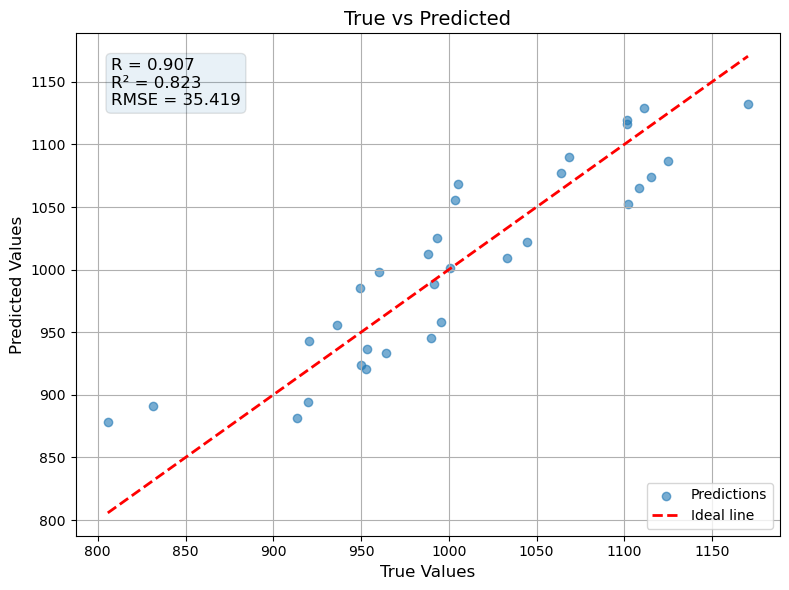

In [854]:
# 14. Строим график паритета
plot_true_vs_predicted(y, y_model, title="True vs Predicted", figsize=(8, 6))

In [855]:
# 15. Сохраним данные на будущее для кросс валидации
X_ffe = X.copy()
y_ffe = y.copy()
b_ffe = b.copy()

# 2. Латинский гиперкуб
### общие сведения здесь: https://en.wikipedia.org/wiki/Latin_hypercube_sampling

# 2.1. Построение литинского гиперкуба

In [856]:
def latin_hypercube(n_factors, n_samples, min_val=-1.0, max_val=1.0, random_seed=None):
    """
    Генерирует выборку по методу латинского гиперкуба (LHS).
    
    Параметры:
        n_factors (int): количество факторов (переменных).
        n_samples (int): количество точек (размер выборки).
        min_val (float): нижняя граница диапазона (по умолчанию -1.0).
        max_val (float): верхняя граница диапазона (по умолчанию 1.0).
        random_seed (int or None): seed для воспроизводимости.
    
    Возвращает:
        list of lists: матрица размером n_samples × n_factors.
    """
    if n_factors < 2 or n_samples < 2:
        raise ValueError("n_factors и n_samples должны быть > 1")
    
    if random_seed is not None:
        random.seed(random_seed)
    
    # ОПределяем ширину интервала в котором мы будем определять значение фактора  
    interval_width = (max_val - min_val) / n_samples
    
    # Заготовка для матрицы: n_samples строк, n_factors столбцов
    design = [[0.0 for _ in range(n_factors)] for _ in range(n_samples)]

    # итерируем по количеству факторов, т.е. по количеству столбцов матрицы
    for factor in range(n_factors):
        # Генерируем случайную перестановку индексов интервалов: [0, 1, ..., n_samples-1]
        # Это сделано для того, что бы каждый фактор изменялся в случайном порядке, а не монотонно возрастал (или падал)
        # сначала создаем список где записаны номера каждого из интервалов
        intervals = list(range(n_samples))
        # после этого перемешиваем этот список
        random.shuffle(intervals)
        # итерируем по количеству экспериментов (т.е. по количеству строк матрицы):
        for i in range(n_samples):
            # для кождого интервала определяем его индекс (берем его из списка intervals)
            interval_index = intervals[i]
            # Выбираем случайную точку внутри интервала
            # сначала минимально возможное значение
            low = min_val + interval_index * interval_width
            # затем максимальное
            high = low + interval_width
            # после этого берем случайное число в диапазоне от low до high опираясь на закон нормального распределения
            value = random.uniform(low, high)
            # записываем это значение в матрицу. первый индекс [i] - номер эксперимента, второй индекс [factor] - номер фактора
            design[i][factor] = value
   
    return design

In [857]:
# 3 фактора, 10 точек, диапазон [-1, +1], воспроизводимо
latin_hypercube(3, 10, min_val=0, max_val=1, random_seed=1488)

[[0.025142581950515875, 0.448523807360954, 0.9443561345932557],
 [0.5576963561149229, 0.09888736694797313, 0.5567607437955282],
 [0.6232874026510312, 0.8080026389431331, 0.8660351074080417],
 [0.754180441417748, 0.9807082805032052, 0.4913772184360544],
 [0.33414021373233777, 0.5830861672137243, 0.34671033204526375],
 [0.9958325514576516, 0.7329457432179028, 0.02582493866335276],
 [0.14676231734387246, 0.6541817972231526, 0.680496243382601],
 [0.85299212625262, 0.12402978983086971, 0.7956950203173361],
 [0.26854158609342244, 0.36210551484941994, 0.14077937157452952],
 [0.4153737809457117, 0.2438766416161782, 0.24199653316408906]]

In [858]:
# проверска что дает стандартная библиотека pyDOE3:
doe.lhs(3, 10, seed=1488)
# идентичного результата добиться не получится из-за присутсвия случайных чисел

array([[0.68189366, 0.48275015, 0.93469075],
       [0.7630064 , 0.06361354, 0.41169396],
       [0.21926656, 0.7347545 , 0.51954848],
       [0.02752672, 0.96696319, 0.80371008],
       [0.57826347, 0.69888599, 0.21656191],
       [0.9305884 , 0.88941252, 0.14010528],
       [0.87048217, 0.1915143 , 0.38901457],
       [0.40544068, 0.55195264, 0.02252059],
       [0.19100231, 0.21933029, 0.70377193],
       [0.34231147, 0.34997858, 0.66329701]])

# 2.2. Построение модели на основе латинского гиперкуба.
## Латинский гиперкуб - более универсальная матрица и может быть использована для следующих задач:
- Построение линейных моделей. Это менее эффективно, чем использование ПФЭ, но теоретически возможно;
- Построение более сложных моделей типа градиентного бустинга или нейронной сети.

Необходимо отметить, что с случае построения линейной модели расчет производится аналогично ПФЭ.
# 2.2.1 Пример линейной модели на основе латинского гиперкуба (задача аналогичная, что и в пункте 1.2.2.)


In [859]:
# Пример на основе искуственно сгенерированных данных

# 1. Генерим латинский гиперкуб для 5 факторов (т.к. в функции 5 переменных) и 10 экспериментов (можно больше можно меньше)
matrix = latin_hypercube(5, 10, min_val=-1.0, max_val=1.0, random_seed=1488)
matrix_lhh = matrix.copy()
# 2. Добавляем в нее столбец с единицами для определения свободного коэффициента
matrix = add_intercept_column(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(matrix)
# 4. Определим границы варьируемых параметров
limits = [(4.75, 5.5), (2.8, 3.3), (0.65, 1.15), (0.2, 0.8), (17.0, 21.0)]

# 5. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X, dtype=float)
natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 6. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i + 1]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i + 1] = natural_column
# 7. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    nb, mo, ti, al, cr = natural_matrix[i, 1:6]
    print(f'Эксперимент # {i+1}: Nb = {nb:.2f}, Mo = {mo:.2f}, Ti = {ti:.2f}, Al = {al:.2f}, Cr = {cr:.2f}')  

Эксперимент # 1: Nb = 4.77, Mo = 3.02, Ti = 1.12, Al = 0.64, Cr = 19.71
Эксперимент # 2: Nb = 5.17, Mo = 2.85, Ti = 0.93, Al = 0.38, Cr = 18.48
Эксперимент # 3: Nb = 5.22, Mo = 3.20, Ti = 1.08, Al = 0.46, Cr = 17.92
Эксперимент # 4: Nb = 5.32, Mo = 3.29, Ti = 0.90, Al = 0.41, Cr = 17.37
Эксперимент # 5: Nb = 5.00, Mo = 3.09, Ti = 0.82, Al = 0.27, Cr = 20.69
Эксперимент # 6: Nb = 5.50, Mo = 3.17, Ti = 0.66, Al = 0.78, Cr = 20.34
Эксперимент # 7: Nb = 4.86, Mo = 3.13, Ti = 0.99, Al = 0.56, Cr = 17.67
Эксперимент # 8: Nb = 5.39, Mo = 2.86, Ti = 1.05, Al = 0.72, Cr = 20.05
Эксперимент # 9: Nb = 4.95, Mo = 2.98, Ti = 0.72, Al = 0.51, Cr = 18.88
Эксперимент # 10: Nb = 5.06, Mo = 2.92, Ti = 0.77, Al = 0.26, Cr = 19.34


In [860]:
#### 8. Определим вектор выходной функции (предел текучести)
y = np.array ([
               1031.01,  #1
               1058.07,  #2
               1084.67,  #3
               1055.45,  #4
               1034.27,  #5 
               1012.81,  #6 
               1018.51,  #7
               1110.67,  #8 
               990.88,   #9
               1014.16   #10 
              ])
# 9. Посмотрим на весь датасет
print ('Матрица ПФЭ в натуральном масштабе вместе с выходной переменной') 
for i in range(len(natural_matrix)):
    nb, mo, ti, al, cr = natural_matrix[i, 1:6]
    sigma_02 = y[i]
    print(f'Эксперимент # {i+1}: Nb = {nb:.3f}, Mo = {mo:.3f}, Ti = {ti:.3f}, Al = {al:.3f}, Cr = {cr:.3f}, Sigma02 = {sigma_02:.3f}')

Матрица ПФЭ в натуральном масштабе вместе с выходной переменной
Эксперимент # 1: Nb = 4.769, Mo = 3.024, Ti = 1.122, Al = 0.643, Cr = 19.715, Sigma02 = 1031.010
Эксперимент # 2: Nb = 5.168, Mo = 2.849, Ti = 0.928, Al = 0.379, Cr = 18.481, Sigma02 = 1058.070
Эксперимент # 3: Nb = 5.217, Mo = 3.204, Ti = 1.083, Al = 0.464, Cr = 17.918, Sigma02 = 1084.670
Эксперимент # 4: Nb = 5.316, Mo = 3.290, Ti = 0.896, Al = 0.410, Cr = 17.370, Sigma02 = 1055.450
Эксперимент # 5: Nb = 5.001, Mo = 3.092, Ti = 0.823, Al = 0.268, Cr = 20.691, Sigma02 = 1034.270
Эксперимент # 6: Nb = 5.497, Mo = 3.166, Ti = 0.663, Al = 0.784, Cr = 20.338, Sigma02 = 1012.810
Эксперимент # 7: Nb = 4.860, Mo = 3.127, Ti = 0.990, Al = 0.564, Cr = 17.666, Sigma02 = 1018.510
Эксперимент # 8: Nb = 5.390, Mo = 2.862, Ti = 1.048, Al = 0.723, Cr = 20.050, Sigma02 = 1110.670
Эксперимент # 9: Nb = 4.951, Mo = 2.981, Ti = 0.720, Al = 0.511, Cr = 18.885, Sigma02 = 990.880
Эксперимент # 10: Nb = 5.062, Mo = 2.922, Ti = 0.771, Al = 0.259

In [861]:
# 10. Расчитываем коэффициенты линейной регрессии по нормальному уравнению
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ X.T @ y
# 12. Проверяем расчетные значения y
y_model = X @ b
# 11. Сравниваем модельное и расчетное значение y
print ('-------------------------------------------------------------')
print ('Сравнение модельных и истинных значений для заданной матрицы:')
for i in range (len(y)):
    print (f'Эксперимент № {i}: y_model = {y_model[i]:.1f}, y = {y[i]} ')
print(f"Коэффициент детерминации (R²): {r_2(y, y_model):.2f}")
print(f"Среднеквадратичная ошибка (RMSE): {rmse(y, y_model):.2f}")
print ('-------------------------------------------------------------')

-------------------------------------------------------------
Сравнение модельных и истинных значений для заданной матрицы:
Эксперимент № 0: y_model = 1039.6, y = 1031.01 
Эксперимент № 1: y_model = 1063.0, y = 1058.07 
Эксперимент № 2: y_model = 1084.6, y = 1084.67 
Эксперимент № 3: y_model = 1054.5, y = 1055.45 
Эксперимент № 4: y_model = 1026.6, y = 1034.27 
Эксперимент № 5: y_model = 1019.8, y = 1012.81 
Эксперимент № 6: y_model = 1016.0, y = 1018.51 
Эксперимент № 7: y_model = 1101.9, y = 1110.67 
Эксперимент № 8: y_model = 981.0, y = 990.88 
Эксперимент № 9: y_model = 1023.6, y = 1014.16 
Коэффициент детерминации (R²): 0.96
Среднеквадратичная ошибка (RMSE): 6.91
-------------------------------------------------------------


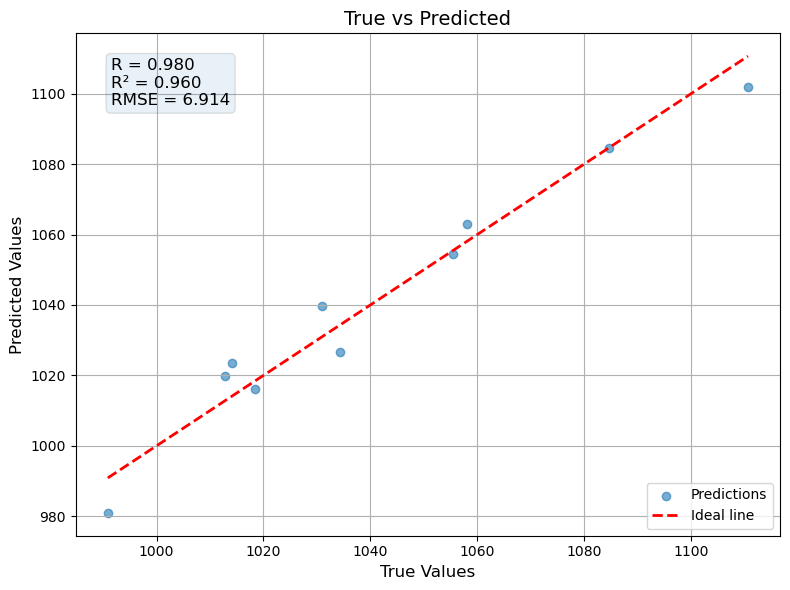

In [862]:
# 13. Строим график паритета
plot_true_vs_predicted(y, y_model, title="True vs Predicted", figsize=(8, 6))

In [863]:
# 14. Сохраняем данные для кросс валидации
matrix_lhh = matrix_lhh.copy()
X_lhh = X.copy()
y_lhh = y.copy()
b_lhh = b.copy()

# 3. Кросс-валидация моделей на основе ПФЭ и латинского гиперкуба 
### Проверяем модель на основе ПФЭ на данных полученных при построении модели с помощью латинского гиперкуба и наоборот.

# 3.1. Проверка линейной модели на основе ПФЭ данными полученными с помощью латинского гиперкуба.

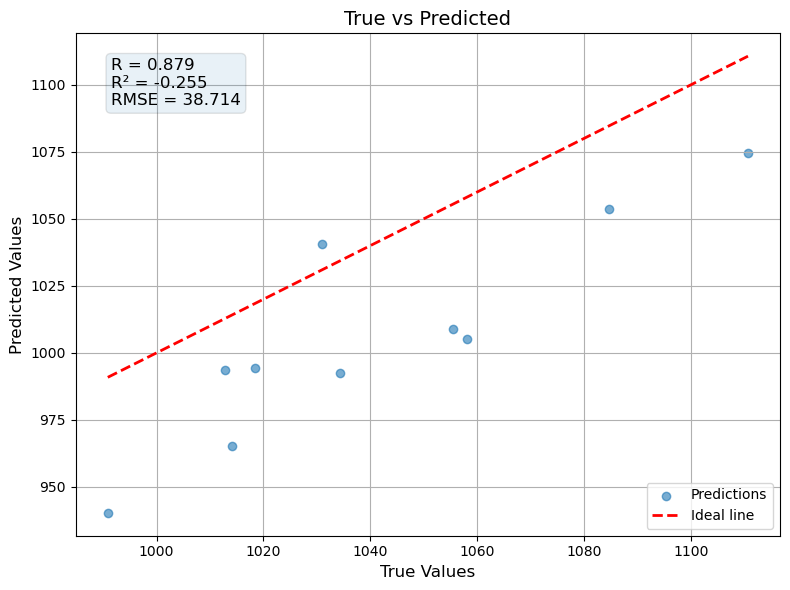

In [864]:
# Посчитаем значение предела текучести по коэффициентам b_ffe, но на данных из матрицы X_lhh
y_model = X_lhh @ b_ffe
# Посмотрим на график паритета для этого случая
plot_true_vs_predicted(y_llh, y_model, title="True vs Predicted", figsize=(8, 6))


# 3.2. Проверка линейной модели на основе латинского гиперкуба данными полученными с помощью ПФЭ.

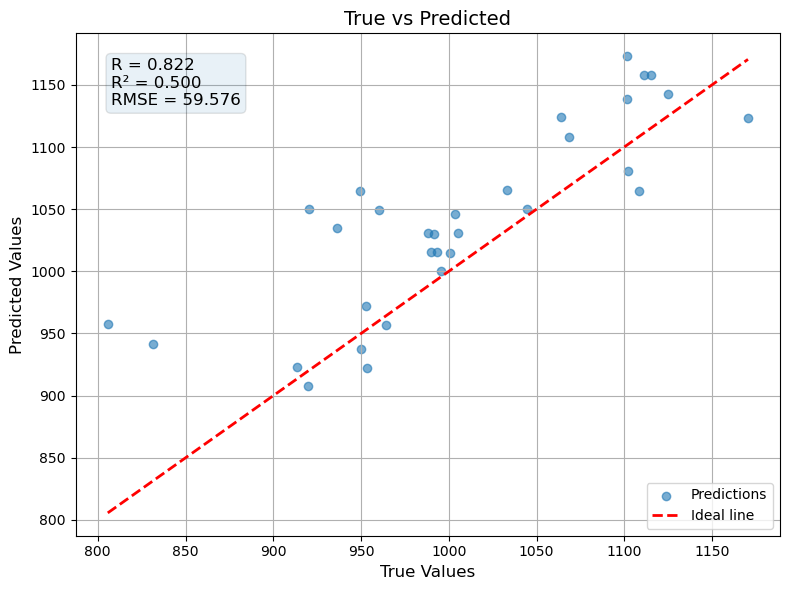

In [865]:
# Посчитаем значение предела текучести по коэффициентам b_lhh, но на данных из матрицы X_ffe
y_model = X_ffe @ b_lhh
# Посмотрим на график паритета для этого случая
plot_true_vs_predicted(y_ffe, y_model, title="True vs Predicted", figsize=(8, 6))

# 4. План Плакетта-Бермана
### (отсеивающий эксперимент)
### общие сведения здесь: https://en.wikipedia.org/wiki/Plackett–Burman_design
# 4.1. Построение матрицы Плакетта-Бермана

In [866]:
# вспомогательные функции для построения матриц Тёплица и Ганкеля 
def toeplitz(first_col, first_row):
    """Создаёт матрицу Тёплица из первого столбца и первой строки."""
    if first_col[0] != first_row[0]:
        raise ValueError("Первый элемент столбца и строки должен совпадать.")
    
    m = len(first_col)  # количество строк
    n = len(first_row)  # количество столбцов

    # Создаём пустую матрицу m x n (заполненную нулями)
    matrix = [[0 for _ in range(n)] for _ in range(m)]

    # Заполняем матрицу
    for i in range(m):
        for j in range(n):
            if j >= i:
                matrix[i][j] = first_row[j - i]
            else:
                matrix[i][j] = first_col[i - j]
    
    return matrix

def hankel(first_col, last_row):
    """Создаёт квадратную матрицу Ганкеля из первого столбца и последней строки."""
    m = len(first_col)
    if len(last_row) != m:
        raise ValueError("first_col и last_row должны иметь одинаковую длину.")
    
    # Формируем полную последовательность: first_col + last_row[1:]
    seq = first_col + last_row[1:]  # длина = 2*m - 1

    # Создаём пустую квадратную матрицу m x m
    matrix = [[0 for _ in range(m)] for _ in range(m)]

    # Заполняем матрицу: элемент (i, j) берётся из seq[i + j]
    for i in range(m):
        for j in range(m):
            matrix[i][j] = seq[i + j]
    
    return matrix


In [867]:
# пример построения матрицы Тёплица
toeplitz_matrix = toeplitz ([1, 2, 3, 4, 5, 6, 7], [1, 70, 30, 40, 5, 6, 7, 90])
for item in toeplitz_matrix:
    print (item)

[1, 70, 30, 40, 5, 6, 7, 90]
[2, 1, 70, 30, 40, 5, 6, 7]
[3, 2, 1, 70, 30, 40, 5, 6]
[4, 3, 2, 1, 70, 30, 40, 5]
[5, 4, 3, 2, 1, 70, 30, 40]
[6, 5, 4, 3, 2, 1, 70, 30]
[7, 6, 5, 4, 3, 2, 1, 70]


In [868]:
# пример построения матрицы Генкеля
henkel_matrix = hankel([1, 2, 3, 4, 5, 6, 7], [7, 8, 9, 10, 11, 12, 13])
for item in henkel_matrix:
    print (item)

[1, 2, 3, 4, 5, 6, 7]
[2, 3, 4, 5, 6, 7, 8]
[3, 4, 5, 6, 7, 8, 9]
[4, 5, 6, 7, 8, 9, 10]
[5, 6, 7, 8, 9, 10, 11]
[6, 7, 8, 9, 10, 11, 12]
[7, 8, 9, 10, 11, 12, 13]


In [869]:
# Вспомогательные функции:
# для преобразования Кренекера
# для поворота матрицы по верикали
# для проверки является ли число x положительной степенью двойки
def kronecker_double(matrix):
    """Преобразует matrix → [[matrix, matrix], [matrix, -matrix]]"""
    top = [row + row for row in matrix]
    bottom = [row + [-x for x in row] for row in matrix]
    return top + bottom

def flipud(matrix):
    """Переворачивает матрицу по вертикали."""
    return matrix[::-1]

def is_power_of_two(x):
    """
    Проверяет, является ли x положительной степенью двойки.
    Использует двоичное представление в виде строки.
    
    Примеры:
        is_power_of_two(1)  → True   # 1 = 2^0
        is_power_of_two(8)  → True   # 1000₂
        is_power_of_two(6)  → False  # 110₂
        is_power_of_two(0)  → False
    """
    if not isinstance(x, int) or x <= 0:
        return False
    
    # Получаем двоичное представление: bin(8) → '0b1000'
    binary_repr = bin(x)  # например, '0b1010'
    
    # Считаем, сколько раз встречается символ '1'
    count_ones = binary_repr.count('1')
    
    # Степень двойки ⇨ ровно одна '1' в двоичной записи
    return count_ones == 1


In [870]:
doubles_matrix = kronecker_double (henkel_matrix)
for item in doubles_matrix:
    print (item)

[1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7]
[2, 3, 4, 5, 6, 7, 8, 2, 3, 4, 5, 6, 7, 8]
[3, 4, 5, 6, 7, 8, 9, 3, 4, 5, 6, 7, 8, 9]
[4, 5, 6, 7, 8, 9, 10, 4, 5, 6, 7, 8, 9, 10]
[5, 6, 7, 8, 9, 10, 11, 5, 6, 7, 8, 9, 10, 11]
[6, 7, 8, 9, 10, 11, 12, 6, 7, 8, 9, 10, 11, 12]
[7, 8, 9, 10, 11, 12, 13, 7, 8, 9, 10, 11, 12, 13]
[1, 2, 3, 4, 5, 6, 7, -1, -2, -3, -4, -5, -6, -7]
[2, 3, 4, 5, 6, 7, 8, -2, -3, -4, -5, -6, -7, -8]
[3, 4, 5, 6, 7, 8, 9, -3, -4, -5, -6, -7, -8, -9]
[4, 5, 6, 7, 8, 9, 10, -4, -5, -6, -7, -8, -9, -10]
[5, 6, 7, 8, 9, 10, 11, -5, -6, -7, -8, -9, -10, -11]
[6, 7, 8, 9, 10, 11, 12, -6, -7, -8, -9, -10, -11, -12]
[7, 8, 9, 10, 11, 12, 13, -7, -8, -9, -10, -11, -12, -13]


In [871]:
# функции для построения базовых матриц 12x12 и 20x20 и частный случай для 27 варьируемых параметров
def _pb_base_12():
    """Возвращает базовую PB-матрицу размера 12×12."""
    c = [-1, -1, 1, -1, -1, -1, 1, 1, 1, -1, 1]      # первый столбец (без первой строки)
    r = [-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1]      # первая строка (без первого элемента)
    T = toeplitz(c, r)                               # 11×11
    H = [[1] * 12]                                    # первая строка: все +1
    for i in range(11):
        H.append([1] + T[i])                          # добавляем столбец +1 слева
    return H


def _pb_base_20():
    """Возвращает базовую PB-матрицу размера 20×20."""
    c = [-1, -1, 1, 1, -1, -1, -1, -1, 1, -1,
         1, -1, 1, 1, 1, 1, -1, -1, 1]               # длина 19
    r = [1, -1, -1, 1, 1, -1, -1, -1, -1, 1,
         -1, 1, -1, 1, 1, 1, 1, -1, -1]              # длина 19
    Hk = hankel(c, r)                                # 19×19
    H = [[1] * 20]                                    # первая строка
    for i in range(19):
        H.append([1] + Hk[i])
    return H

def _pb_base_28():
    """ Частный случай для 27 варьируемых параметров"""
    kernel = [
        1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1,
        1, -1, 1, 1, 1, -1, -1, -1, -1, 1, -1,
        -1, 1, -1, 1, -1
    ]  # длина 27
    # Строим циклическую матрицу: каждая следующая строка — сдвиг предыдущей
    H = [[1] + kernel]
    for i in range(27):
        # Циклический сдвиг kernel вправо
        kernel = [kernel[-1]] + kernel[:-1]
        H.append([1] + kernel)
    return H

In [872]:
base_12 = _pb_base_12()
base_12 = flipud(base_12)
for item in base_12:
    print (item)

[1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1, -1]
[1, -1, 1, 1, 1, -1, -1, -1, 1, -1, -1, 1]
[1, 1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1]
[1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1]
[1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1]
[1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, 1]
[1, -1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1]
[1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1, -1]
[1, 1, -1, -1, 1, -1, 1, 1, 1, -1, -1, -1]
[1, -1, -1, 1, -1, 1, 1, 1, -1, -1, -1, 1]
[1, -1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [873]:
# основная функция для построения матрицы Плакетта-Бермана

def pbdesign(n):
    ''' Возвращает матрицу Плакетта-Бермана для заданного количества варьируемых параметров n (int) '''
    
    if not isinstance(n, int) or n < 3 or n > 31:
        raise ValueError("n должно быть целое числа в диапазоне от 3 до 31")
    

    keep = n
    # определяем наименьшее число, кратное 4, которое больше n
    N = 4 * ((n // 4) + 1)

    # Определяем базовую матрицу и количество удвоений
     # Случай 1: N = 1 * 2^e
    if is_power_of_two(N):
        base_H = [[1]]
        e = N.bit_length() - 1  # потому что 2^e = N → e = log2(N)
    # Случай 2: N = 12 * 2^e
    elif N % 12 == 0 and is_power_of_two(N // 12):
        base_H = _pb_base_12()
        e = (N // 12).bit_length() - 1
    # Случай 3: N = 20 * 2^e
    elif N % 20 == 0 and is_power_of_two(N // 20):
        base_H = _pb_base_20()
        e = (N // 20).bit_length() - 1
    # Частный случай для n = 27
    elif N == 28:
        base_H = _pb_base_28()
        e = 0
    else:
        raise ValueError(
            f"Plackett-Burman design not supported for n={n} (N={N}). "
            "Supported N: 2^e, 12·2^e, or 20·2^e (e ≥ 0)."
        )

    H = base_H
    for _ in range(e):
        H = kronecker_double(H)

    H = [row[1 : keep + 1] for row in H]
    H = flipud(H)
    return H

In [874]:
matrix = pbdesign (11)
for item in matrix:
    print (item)

[1, -1, 1, 1, 1, -1, -1, -1, 1, -1, -1]
[-1, 1, 1, 1, -1, -1, -1, 1, -1, -1, 1]
[1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1]
[1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1]
[1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1]
[-1, -1, -1, 1, -1, -1, 1, -1, 1, 1, 1]
[-1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1]
[-1, 1, -1, -1, 1, -1, 1, 1, 1, -1, -1]
[1, -1, -1, 1, -1, 1, 1, 1, -1, -1, -1]
[-1, -1, 1, -1, 1, 1, 1, -1, -1, -1, 1]
[-1, 1, -1, 1, 1, 1, -1, -1, -1, 1, -1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [875]:
# проверска что дает стандартная библиотека pyDOE3:
doe.pbdesign(31)

array([[-1., -1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1., -1.,
        -1.,  1., -1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1., -1.,
         1., -1.,  1.,  1., -1.],
       [ 1., -1., -1., -1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,
        -1., -1., -1., -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1.,
        -1., -1., -1.,  1.,  1.],
       [-1.,  1., -1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,  1., -1.,
         1., -1., -1.,  1., -1.,  1.,  1., -1.,  1., -1.,  1., -1.,  1.,
        -1., -1.,  1., -1.,  1.],
       [ 1.,  1.,  1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,
         1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1., -1., -1., -1., -1.],
       [-1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1., -1.,  1.,
         1., -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1., -1., -1.,
         1.,  1., -1., -1.,  1.],
       [ 1., -1., -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1., -1., -1.,
         1.,  1., -1., -1.,

# 4.2. Пример использования матрицы Плакетта-Бермана для анализа зависимости предела текучести сплава Inconel 718 от хим. состава и параметров термической обработки.

Исследуем влияние химического состава:
- $ X_1 $:  содержание Nb (4.75% – 5.50%)
- $ X_2 $:  содержание Mo (2.8% – 3.3%)
- $ X_3 $:  содержание Ti (0.65% – 1.15%)
- $ X_4 $:  содержание Al (0.2% – 0.8%)
- $ X_5 $:  содержание Cr (17.0% – 21.0%)

Параметры термической обработки:
- $ X_6 $:  температура закалки (1000 $^\circ\mathrm{C}$ - 1050 $^\circ\mathrm{C}$)
- $ X_7 $:  скорость охлаждения при закалке (5 $^\circ\mathrm{C}/сек $ - 15 $^\circ\mathrm{C}/сек $)
- $ X_8 $:  температура искуственного старения (770 $^\circ\mathrm{C}$ - 806 $^\circ\mathrm{C}$)
- $ X_9 $:  время искуственного старения (6 часов - 10 часов)

In [876]:
# 1. Генерим матрицу Плакетта-Бермана для 9 факторов
matrix = pbdesign (9)
# 2. Добавляем в нее столбец с единицами для определения свободного коэффициента
matrix = add_intercept_column(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(matrix)
# 4. Посмотрим на получившуюся матрицу
#X
# 5. Определим границы варьируемых параметров
limits = [(4.75, 5.5), (2.8, 3.3), (0.65, 1.15), (0.2, 0.8), (17.0, 21.0),
         (1000,1050), (5, 15), (770, 805), (6.0, 10.0)]

# 6. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X, dtype=float)
natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 7. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i + 1]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i + 1] = natural_column
# 8. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    nb, mo, ti, al, cr, Tzak, cooling_rate, Tage, tage  = natural_matrix[i, 1:10]
    print(f'Эксперимент # {i+1}: Nb = {nb:.2f}, Mo = {mo:.2f}, Ti = {ti:.2f}, Al = {al:.1f}, Cr = {cr:.1f}, '
         f'Tзак = {Tzak:.0f}, Cooling rate = {cooling_rate:.0f}, Tage = {Tage:.0f}, tage = {tage:.0f}')   


Эксперимент # 1: Nb = 5.50, Mo = 2.80, Ti = 1.15, Al = 0.8, Cr = 21.0, Tзак = 1000, Cooling rate = 5, Tage = 770, tage = 10
Эксперимент # 2: Nb = 4.75, Mo = 3.30, Ti = 1.15, Al = 0.8, Cr = 17.0, Tзак = 1000, Cooling rate = 5, Tage = 805, tage = 6
Эксперимент # 3: Nb = 5.50, Mo = 3.30, Ti = 1.15, Al = 0.2, Cr = 17.0, Tзак = 1000, Cooling rate = 15, Tage = 770, tage = 6
Эксперимент # 4: Nb = 5.50, Mo = 3.30, Ti = 0.65, Al = 0.2, Cr = 17.0, Tзак = 1050, Cooling rate = 5, Tage = 770, tage = 10
Эксперимент # 5: Nb = 5.50, Mo = 2.80, Ti = 0.65, Al = 0.2, Cr = 21.0, Tзак = 1000, Cooling rate = 5, Tage = 805, tage = 6
Эксперимент # 6: Nb = 4.75, Mo = 2.80, Ti = 0.65, Al = 0.8, Cr = 17.0, Tзак = 1000, Cooling rate = 15, Tage = 770, tage = 10
Эксперимент # 7: Nb = 4.75, Mo = 2.80, Ti = 1.15, Al = 0.2, Cr = 17.0, Tзак = 1050, Cooling rate = 5, Tage = 805, tage = 10
Эксперимент # 8: Nb = 4.75, Mo = 3.30, Ti = 0.65, Al = 0.2, Cr = 21.0, Tзак = 1000, Cooling rate = 15, Tage = 805, tage = 10
Эксперим

In [877]:
# 9. Определим вектор выходной функции (предел текучести)
y = np.array ([
               1027.63,   #1
                966.18,   #2
                1172.22,  #3
                1020.25,  #4
                892.97,   #5
                973.27,   #6
                912.67,   #7
                817.2,    #8
                954.79,   #9
                1176.34,  #10
                1014.46,  #11
                1206.12   #12
                ])

# 10. Выыодим данные вместе с выходной переменной
for i in range(len(natural_matrix)):
    nb, mo, ti, al, cr, Tzak, cooling_rate, Tage, tage  = natural_matrix[i, 1:10]
    print(f'Эксп. # {i+1}: Nb = {nb:.2f}, Mo = {mo:.2f}, Ti = {ti:.2f}, Al = {al:.1f}, Cr = {cr:.1f}, '
         f'Tзак = {Tzak:.0f}, Cooling rate = {cooling_rate:.0f}, Tage = {Tage:.0f}, tage = {tage:.0f}, Sigma02 = {y[i]:.1f}')

Эксп. # 1: Nb = 5.50, Mo = 2.80, Ti = 1.15, Al = 0.8, Cr = 21.0, Tзак = 1000, Cooling rate = 5, Tage = 770, tage = 10, Sigma02 = 1027.6
Эксп. # 2: Nb = 4.75, Mo = 3.30, Ti = 1.15, Al = 0.8, Cr = 17.0, Tзак = 1000, Cooling rate = 5, Tage = 805, tage = 6, Sigma02 = 966.2
Эксп. # 3: Nb = 5.50, Mo = 3.30, Ti = 1.15, Al = 0.2, Cr = 17.0, Tзак = 1000, Cooling rate = 15, Tage = 770, tage = 6, Sigma02 = 1172.2
Эксп. # 4: Nb = 5.50, Mo = 3.30, Ti = 0.65, Al = 0.2, Cr = 17.0, Tзак = 1050, Cooling rate = 5, Tage = 770, tage = 10, Sigma02 = 1020.2
Эксп. # 5: Nb = 5.50, Mo = 2.80, Ti = 0.65, Al = 0.2, Cr = 21.0, Tзак = 1000, Cooling rate = 5, Tage = 805, tage = 6, Sigma02 = 893.0
Эксп. # 6: Nb = 4.75, Mo = 2.80, Ti = 0.65, Al = 0.8, Cr = 17.0, Tзак = 1000, Cooling rate = 15, Tage = 770, tage = 10, Sigma02 = 973.3
Эксп. # 7: Nb = 4.75, Mo = 2.80, Ti = 1.15, Al = 0.2, Cr = 17.0, Tзак = 1050, Cooling rate = 5, Tage = 805, tage = 10, Sigma02 = 912.7
Эксп. # 8: Nb = 4.75, Mo = 3.30, Ti = 0.65, Al = 0.2,

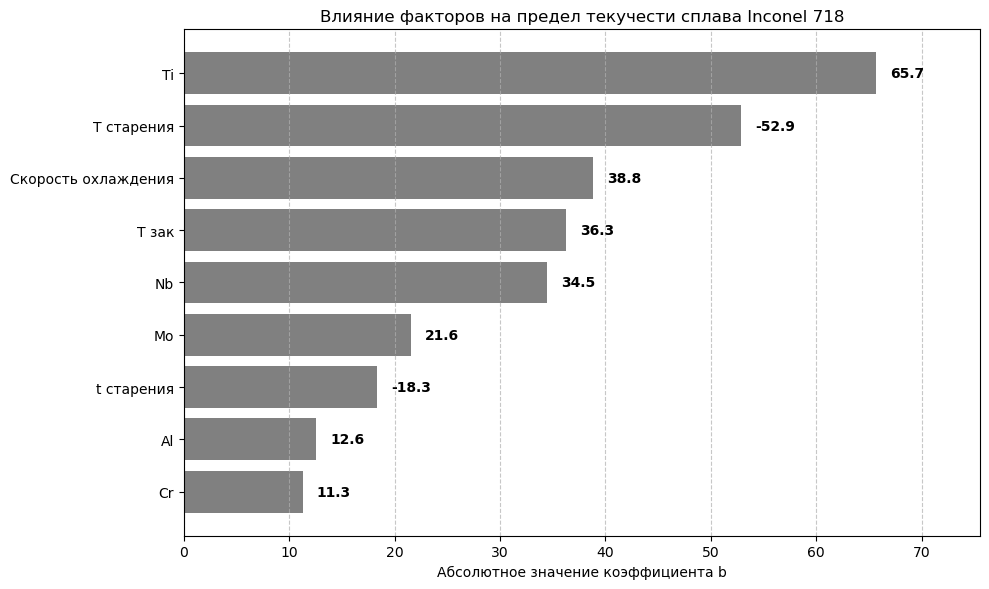

In [878]:
# 11. Расчитываем коэффициенты линейной регрессии по нормальному уравнению
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ X.T @ y
# 12. Строим диаграмму Парето для коэффициентов начиная с b1
factor_names = ['Nb', 'Mo', 'Ti', 'Al', 'Cr', 'T зак', 'Скорость охлаждения', 'T старения', 't старения']

# Извлекаем коэффициенты факторов (без b0)
b_factors = b[1:] 

# Считаем абсолютные значения
abs_b = np.abs(b_factors)

# индексы в порядке убывания величины abs_b 
indices = np.argsort(abs_b)[::-1]

sorted_factors = np.array(factor_names)[indices]
sorted_abs_b = abs_b[indices]
sorted_b = b_factors[indices]

# Построение диаграммы Парето
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_factors, sorted_abs_b, color='grey')
plt.xlabel('Абсолютное значение коэффициента b')
plt.title('Влияние факторов на предел текучести сплава Inconel 718')
plt.gca().invert_yaxis()  # Самый важный — сверху
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, max(sorted_abs_b) * 1.15)

# Добавим значения на бары (фактические коэффициенты, не абсолютные)
offset = max(sorted_abs_b) * 0.02  # небольшой отступ
for i, (coef, abs_val) in enumerate(zip(sorted_b, sorted_abs_b)):
    plt.text(abs_val + offset, i, f'{coef:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Построение поверхностей отклика (уравнений регрессии второго порядка)

Модель поверхности отклика — это **квадратичная регрессионная модель**, позволяющая описывать нелинейные (в частности, криволинейные) зависимости отклика от факторов.

**Общая форма квадратичной модели поверхности отклика:**

$$
\hat{y} = b_0 + \sum_{i=1}^{n} b_i x_i + \sum_{i=1}^{n} b_{ii} x_i^2 + \sum_{i=1}^{n-1} \sum_{j=i+1}^{n} b_{ij} x_i x_j
$$

где:  
- $ n $ — число факторов,  
- $ x_i $ — кодированные значения $ i $-го фактора (обычно $ -1, 0, +1 $),  
- $ b_0 $ — свободный член (оценка отклика в центре плана),  
- $ b_i $ — коэффициенты при линейных эффектах,  
- $ b_{ii} $ — коэффициенты при квадратичных (нелинейных) эффектах,  
- $ b_{ij} $ — коэффициенты при парных взаимодействиях факторов $ x_i $ и $ x_j $.

Для расчёта коэффициента $ b_0 $ в матрицу регрессоров необходимо включить **столбец единиц**, соответствующий свободному члену.

**Векторно-матричная форма модели:**

$$
\hat{\mathbf{y}} = \mathbf{X} \mathbf{b},
$$

где:  
- $ \mathbf{X} $ — расширенная матрица регрессоров размером $ m \times p $,  
  - $ m $ — количество опытов (строк плана),  
  - $ p = 1 + n + n + \frac{n(n-1)}{2} = 1 + 2n + \frac{n(n-1)}{2} $ — общее число параметров модели (свободный член, линейные, квадратичные и взаимодействия),  
- $ \mathbf{y} $ — вектор наблюдаемых значений отклика (например, предел текучести сплава Inconel 718) размером $ m $,  
- $ \mathbf{b} $ — вектор неизвестных коэффициентов регрессии размером $ p $.

Коэффициенты $ \mathbf{b} $ находятся из **нормального уравнения**:

$$
\mathbf{b} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

Эта модель позволяет не только предсказывать отклик, но и находить **оптимальные условия** (например, максимум или минимум предела текучести) путём анализа формы поверхности отклика.

# 5.1. Использование плана Бокса-Бенкена
### общие сведения здесь: https://en.wikipedia.org/wiki/Box–Behnken_design

In [825]:
def box_behnken(n_factors, center=1):
    """
    Генерирует план Box-Behnken для построения поверхности отклика.
    
    Параметры:
        n_factors (int): число факторов (>= 3)
        center (int): число центральных точек. Для численного эксперимента достаточно 1.
                      Если передать 0 — центральных точек не будет.
    
    Возвращает:
        list of lists: матрица плана, значения в {-1, 0, +1}
    """
    if n_factors < 3:
        raise ValueError("Box-Behnken требует минимум 3 фактора.")
    
    # количество пар факторов
    n_pairs = n_factors * (n_factors - 1) // 2
    # количество строк
    n_rows = 4 * n_pairs + center # здесь center = 1, т.е. один эксперимент в центре плана (где все значения = 0) 
    
    # Создаём матрицу, заполненную нулями
    design = [[0] * n_factors for _ in range(n_rows)]
    
    base_2x2 = [[-1, -1], [-1, 1], [1, -1], [1, 1]]
    
    row_index = 0
    for i in range(n_factors):
        for j in range(i + 1, n_factors):
            for local_row in base_2x2:
                design[row_index][i] = local_row[0]
                design[row_index][j] = local_row[1]
                row_index += 1
        
    return design

def expand_to_rsm_matrix(design):
    """
    Расширяет матрицу плана эксперимента до полной матрицы регрессоров 
    для квадратичной модели поверхности отклика (Response Surface Methodology).
    
    Вход:
        design: list of lists, размерность (n_runs, k_factors),
                значения — числа (-1, 0, +1 или другие кодированные уровни)
    
    Выход:
        list of lists: расширенная матрица X_rsm размерности (n_runs, p),
                       где p = 1 + k + k + k*(k-1)//2
                       порядок столбцов:
                         1. свободный член (все 1)
                         2. линейные эффекты: x1, x2, ..., xk
                         3. квадратичные эффекты: x1^2, x2^2, ..., xk^2
                         4. взаимодействия: x1*x2, x1*x3, ..., x_{k-1}*x_k
    """
    n_runs = len(design)
    if n_runs == 0:
        return []
    k = len(design[0]) # количество варьируемых факторов (столюцов в матрице design)

    # Инициализируем пустую матрицу результатов
    expanded = []

    # Предварительно вычислим индексы для взаимодействий
    interaction_pairs = []
    for i in range(k):
        for j in range(i + 1, k):
            interaction_pairs.append((i, j))

    # Обрабатываем каждую строку
    for row in design:
        new_row = []

        # 1. Свободный член
        new_row.append(1)

        # 2. Линейные члены
        new_row.extend(row)

        # 3. Квадратичные члены
        new_row.extend([x * x for x in row])

        # 4. Парные взаимодействия
        for i, j in interaction_pairs:
            new_row.append(row[i] * row[j])

        expanded.append(new_row)

    return expanded

In [826]:
box_behnken (5)

[[-1, -1, 0, 0, 0],
 [-1, 1, 0, 0, 0],
 [1, -1, 0, 0, 0],
 [1, 1, 0, 0, 0],
 [-1, 0, -1, 0, 0],
 [-1, 0, 1, 0, 0],
 [1, 0, -1, 0, 0],
 [1, 0, 1, 0, 0],
 [-1, 0, 0, -1, 0],
 [-1, 0, 0, 1, 0],
 [1, 0, 0, -1, 0],
 [1, 0, 0, 1, 0],
 [-1, 0, 0, 0, -1],
 [-1, 0, 0, 0, 1],
 [1, 0, 0, 0, -1],
 [1, 0, 0, 0, 1],
 [0, -1, -1, 0, 0],
 [0, -1, 1, 0, 0],
 [0, 1, -1, 0, 0],
 [0, 1, 1, 0, 0],
 [0, -1, 0, -1, 0],
 [0, -1, 0, 1, 0],
 [0, 1, 0, -1, 0],
 [0, 1, 0, 1, 0],
 [0, -1, 0, 0, -1],
 [0, -1, 0, 0, 1],
 [0, 1, 0, 0, -1],
 [0, 1, 0, 0, 1],
 [0, 0, -1, -1, 0],
 [0, 0, -1, 1, 0],
 [0, 0, 1, -1, 0],
 [0, 0, 1, 1, 0],
 [0, 0, -1, 0, -1],
 [0, 0, -1, 0, 1],
 [0, 0, 1, 0, -1],
 [0, 0, 1, 0, 1],
 [0, 0, 0, -1, -1],
 [0, 0, 0, -1, 1],
 [0, 0, 0, 1, -1],
 [0, 0, 0, 1, 1],
 [0, 0, 0, 0, 0]]

In [827]:
expand_to_rsm_matrix (box_behnken (5))

[[1, -1, -1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 1, 0, 0, 0, 1, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, -1, 0, 0, 0, 1, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, -1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, -1, 0, 0, 1, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 0, -1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, -1, 0, 1, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 0, 0, -1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, -1, 1, 0, 0, 0, 1, 0, 0, 0, -1, 0, 0,

# 5.1.1 Пример нелинейной модели на основе плана Бокса-Бенкена. Зависимость предела текучести сплава Inconel 718 от пяти факторов:

## Исследуем влияние химического состава:
- $ X_1 $:  содержание Ti (0.65% – 1.15%)
- $ X_2 $:  содержание Nb (4.75% – 5.50%)

## Исследуем влияние параметров термообработки:
- $ X_3 $:  скорость охлаждения при закалке (5 $^\circ\mathrm{C}/сек $ - 15 $^\circ\mathrm{C}/сек $)
- $ X_4 $:  температура искуственного старения (770 $^\circ\mathrm{C}$ - 806 $^\circ\mathrm{C}$)
- $ X_5 $:  температура закалки (1000 $^\circ\mathrm{C}$ - 1050 $^\circ\mathrm{C}$)

## Остальные факторы поставим на нулевой уровень:

Химический состав (не варьируемые):
- $ X_6 $:  содержание Mo (3.05%)
- $ X_7 $:  содержание Al (0.5%)
- $ X_8 $:  содержание Cr (19.0%)

Параметры закалки (не варьируемые):
- $ X_9 $:  время искуственного старения (8 часов)



In [828]:
# 1. Генерим матрицу Бокса-Бенкена для 5 факторов
matrix = box_behnken (5)
# 2. Добавляем в нее столбец с единицами для определения свободного коэффициента
# matrix = add_intercept_column(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(matrix)
# 4. Посмотрим на получившуюся матрицу
#X
# 5. Определим границы варьируемых параметров
limits = [(0.65, 1.15), (4.75, 5.5), (5, 15), (770, 805), (1000, 1050)]

# 6. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X, dtype=float)
#natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 7. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i] = natural_column
# 8. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    ti, nb,  cooling_rate, Tage, Tzak  = natural_matrix[i, 0:5]
    print(f'Эксперимент # {i+1}: Ti = {ti:.2f}, Nb = {nb:.2f},'
         f'   Cooling rate = {cooling_rate:.0f},  Tage = {Tage:.0f},  Tzak = {Tzak:.0f}')   


Эксперимент # 1: Ti = 0.65, Nb = 4.75,   Cooling rate = 10,  Tage = 788,  Tzak = 1025
Эксперимент # 2: Ti = 0.65, Nb = 5.50,   Cooling rate = 10,  Tage = 788,  Tzak = 1025
Эксперимент # 3: Ti = 1.15, Nb = 4.75,   Cooling rate = 10,  Tage = 788,  Tzak = 1025
Эксперимент # 4: Ti = 1.15, Nb = 5.50,   Cooling rate = 10,  Tage = 788,  Tzak = 1025
Эксперимент # 5: Ti = 0.65, Nb = 5.12,   Cooling rate = 5,  Tage = 788,  Tzak = 1025
Эксперимент # 6: Ti = 0.65, Nb = 5.12,   Cooling rate = 15,  Tage = 788,  Tzak = 1025
Эксперимент # 7: Ti = 1.15, Nb = 5.12,   Cooling rate = 5,  Tage = 788,  Tzak = 1025
Эксперимент # 8: Ti = 1.15, Nb = 5.12,   Cooling rate = 15,  Tage = 788,  Tzak = 1025
Эксперимент # 9: Ti = 0.65, Nb = 5.12,   Cooling rate = 10,  Tage = 770,  Tzak = 1025
Эксперимент # 10: Ti = 0.65, Nb = 5.12,   Cooling rate = 10,  Tage = 805,  Tzak = 1025
Эксперимент # 11: Ti = 1.15, Nb = 5.12,   Cooling rate = 10,  Tage = 770,  Tzak = 1025
Эксперимент # 12: Ti = 1.15, Nb = 5.12,   Cooling rate

In [829]:
# 9. Определим вектор выходной функции (предел текучести)
y = np.array ([
               956.08,   #1
               1014.42,   #2
               1050.25,  #3
               1111.45,  #4
               991.61,   #5
                991.62,  #6
                1088.93,  #7
                1088.93,  #8
               1047.86,   #9
               938.9,   #10
               1140.79 ,  #11
                1047.52,  #12
                957.63,  #13
               991.94,   #14
                1073.28,  #15
                1089.35,  #16
                1011.69,  #17
                1011.72,  #18
                1024.12,  #19
                1083.3,  #20
                1062.41,  #21
                967.82,  #22
                1138.77,  #23
                1036.16,  #24
                1011.36,  #25
                1012.14,  #26
                1014.87,  #27
                1083.57,  #28
                1102.28,  #29
                1003.08,  #30
                1102.29,  #31
                1003.09,  #32
                1022.64,  #33
                1049.03,  #34
                1022.65,  #35
                1049.03,  #36
                1074.1,  #37
                1102.67,  #38
                979.36,  #39
                1003.41,  #40
                1048.57  #41
                ])

                            


In [830]:
# 10. Создаем расширенную матрицу для рсчета коэффициентов квадратичного уравнения
matrix_rsm = expand_to_rsm_matrix(matrix)
# конвертируем ее в NumPy array
X = np.array(matrix_rsm)

# 11. Расчитываем коэффициенты линейной регрессии по нормальному уравнению
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ X.T @ y

# 5.1.2. Проверка поверхности отклика по данными полученными с помощью латинского гиперкуба. 5 варьируемых параметров.

In [831]:
# 1. Генерим матрицу  5 факторов
matrix =  latin_hypercube(5, 10, min_val=-1.0, max_val=1.0, random_seed=1488)
# 2. Расширяем ее до матрицы rms
martix_rms = expand_to_rsm_matrix(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(martix_rms)
# 4. Определим границы варьируемых параметров
limits = [(0.65, 1.15), (4.75, 5.5), (5, 15), (770, 805), (1000, 1050)]

# 5. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X[:,1:6], dtype=float)
#natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 6. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i+1]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i] = natural_column
# 7. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    ti, nb,  cooling_rate, Tage, Tzak  = natural_matrix[i, 0:5]
    print(f'Эксперимент # {i+1}: Ti = {ti:.2f}, Nb = {nb:.2f},'
         f'   Cooling rate = {cooling_rate:.0f},  Tage = {Tage:.0f},  Tzak = {Tzak:.0f}')   


Эксперимент # 1: Ti = 0.66, Nb = 5.09,   Cooling rate = 14,  Tage = 796,  Tzak = 1034
Эксперимент # 2: Ti = 0.93, Nb = 4.82,   Cooling rate = 11,  Tage = 780,  Tzak = 1019
Эксперимент # 3: Ti = 0.96, Nb = 5.36,   Cooling rate = 14,  Tage = 785,  Tzak = 1011
Эксперимент # 4: Ti = 1.03, Nb = 5.49,   Cooling rate = 10,  Tage = 782,  Tzak = 1005
Эксперимент # 5: Ti = 0.82, Nb = 5.19,   Cooling rate = 8,  Tage = 774,  Tzak = 1046
Эксперимент # 6: Ti = 1.15, Nb = 5.30,   Cooling rate = 5,  Tage = 804,  Tzak = 1042
Эксперимент # 7: Ti = 0.72, Nb = 5.24,   Cooling rate = 12,  Tage = 791,  Tzak = 1008
Эксперимент # 8: Ti = 1.08, Nb = 4.84,   Cooling rate = 13,  Tage = 800,  Tzak = 1038
Эксперимент # 9: Ti = 0.78, Nb = 5.02,   Cooling rate = 6,  Tage = 788,  Tzak = 1024
Эксперимент # 10: Ti = 0.86, Nb = 4.93,   Cooling rate = 7,  Tage = 773,  Tzak = 1029


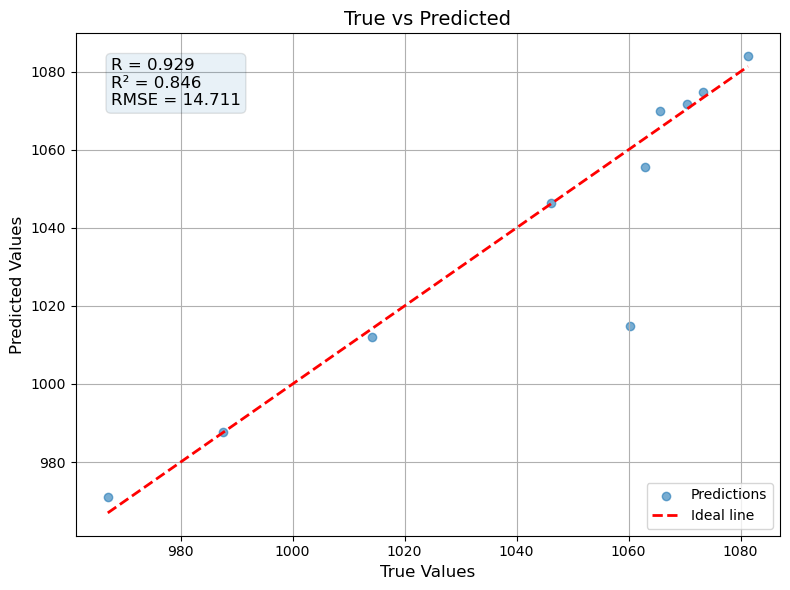

In [832]:
# 8. Определим вектор выходной функции (предел текучести)
y = np.array ([
               966.99,   #1
                1046.07,  #2
                1070.36,    #3
                1073.28,    #4
                1081.33,    #5
                1063.01,    #6
                987.64,    #7
                1060.31,    #8
                1014.23,    #9
                1065.61    #10
               ])
# 9. Расчитаем вектор с помощью модели
y_model = X @ b

# 10. Выведим график паритета
plot_true_vs_predicted(y, y_model, title="True vs Predicted", figsize=(8, 6))

# 11. Сохраним данные на будущее
X_test = X.copy()
y_test = y.copy()

# 5.1.3. Проверка поверхности отклика по данным полученным с помощью латинского гиперкуба. 9 варьируемых параметров.

## Ранее исследованные факторы химического состава:
- $ X_1 $:  содержание Ti (0.65% – 1.15%)
- $ X_2 $:  содержание Nb (4.75% – 5.50%)

## Ранее исследованные факторы параметров термообработки:
- $ X_3 $:  скорость охлаждения при закалке (5 $^\circ\mathrm{C}/сек $ - 15 $^\circ\mathrm{C}/сек $)
- $ X_4 $:  температура искуственного старения (770 $^\circ\mathrm{C}$ - 806 $^\circ\mathrm{C}$)
- $ X_5 $:  температура закалки (1000 $^\circ\mathrm{C}$ - 1050 $^\circ\mathrm{C}$)

## Остальные факторы не исследовались:

Химический состав (не варьируемые):
- $ X_6 $:  содержание Mo (2.8% – 3.3%)
- $ X_7 $:  содержание Al (0.2% – 0.8%)
- $ X_8 $:  содержание Cr (17.0% – 21.0%)

Параметры закалки (не варьируемые):
- $ X_9 $:  время искуственного старения (6 часов - 10 часов)


In [833]:
# 1. Генерим матрицы основных  факторов и факторов, которые не исследовались
matrix =  latin_hypercube(5, 10, min_val=-1.0, max_val=1.0, random_seed=1488)
matrix_add = latin_hypercube(4, 10, min_val=-1.0, max_val=1.0, random_seed=1488) 
# 2. Расширяем ее до матрицы rms
martix_rms = expand_to_rsm_matrix(matrix)
matrix_rms_add = expand_to_rsm_matrix(matrix_add)
# 3. Преобразовываем ее в массив NumPy
X = np.array(martix_rms)
X_add = np.array(matrix_rms_add) 

# 4. Определим границы варьируемых параметров
limits = [(0.65, 1.15), (4.75, 5.5), (5, 15), (770, 805), (1000, 1050)]
limits_add = [(2.8, 3.3), (0.2, 0.8), (17, 21), (6, 10)]

# 5. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X[:,1:6], dtype=float)
natural_matrix_add = np.empty_like(X_add[:,1:5], dtype=float)
#natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 6. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i+1]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i] = natural_column
for i, (x_min, x_max) in enumerate(limits_add):
    coded_column = X_add[:, i+1]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix_add[:, i] = natural_column

# 7. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    ti, nb,  cooling_rate, Tage, Tzak  = natural_matrix[i, 0:5]
    mo, al, cr, tage = natural_matrix_add[i, 0:4]
    print(f'Эксперимент # {i+1}: Ti = {ti:.2f}, Nb = {nb:.2f},'
         f'   Cooling rate = {cooling_rate:.0f},  Tage = {Tage:.0f},  Tzak = {Tzak:.0f}'
         f'   Mo = {mo:.2f}  Al = {al:.2f}   Cr = {cr:.2f}  tage = {tage:.2f}  ')   

Эксперимент # 1: Ti = 0.66, Nb = 5.09,   Cooling rate = 14,  Tage = 796,  Tzak = 1034   Mo = 2.81  Al = 0.47   Cr = 20.78  tage = 8.95  
Эксперимент # 2: Ti = 0.93, Nb = 4.82,   Cooling rate = 11,  Tage = 780,  Tzak = 1019   Mo = 3.08  Al = 0.26   Cr = 19.23  tage = 7.19  
Эксперимент # 3: Ti = 0.96, Nb = 5.36,   Cooling rate = 14,  Tage = 785,  Tzak = 1011   Mo = 3.11  Al = 0.68   Cr = 20.46  tage = 7.76  
Эксперимент # 4: Ti = 1.03, Nb = 5.49,   Cooling rate = 10,  Tage = 782,  Tzak = 1005   Mo = 3.18  Al = 0.79   Cr = 18.97  tage = 7.40  
Эксперимент # 5: Ti = 0.82, Nb = 5.19,   Cooling rate = 8,  Tage = 774,  Tzak = 1046   Mo = 2.97  Al = 0.55   Cr = 18.39  tage = 6.45  
Эксперимент # 6: Ti = 1.15, Nb = 5.30,   Cooling rate = 5,  Tage = 804,  Tzak = 1042   Mo = 3.30  Al = 0.64   Cr = 17.10  tage = 9.89  
Эксперимент # 7: Ti = 0.72, Nb = 5.24,   Cooling rate = 12,  Tage = 791,  Tzak = 1008   Mo = 2.87  Al = 0.59   Cr = 19.72  tage = 8.43  
Эксперимент # 8: Ti = 1.08, Nb = 4.84,   Co

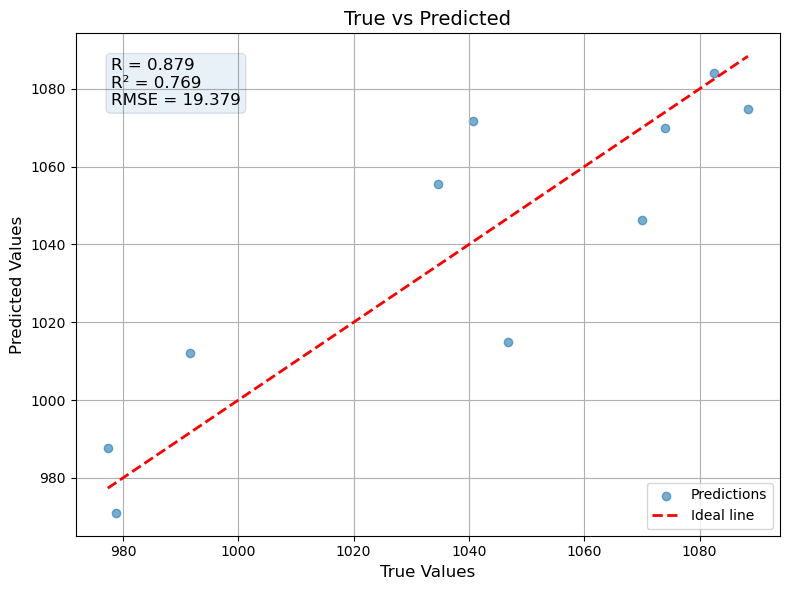

In [834]:
# 8. Определим вектор выходной функции (предел текучести)
y = np.array ([
                978.86,   #1
                1070.08,  #2
                1040.76,  #3
                1088.4,   #4 ошибка
                1082.54,  #5
                1034.61,  #6
                977.37,   #7
                1046.72,  #8
                991.62,   #9
                1074.09   #10
               ])

# 9. Расчитаем вектор с помощью модели
y_model = X @ b

# 10. Выведим график паритета
plot_true_vs_predicted(y, y_model, title="True vs Predicted", figsize=(8, 6))



In [835]:
# сохраним на будущее для проверки последующих моделей
y_test = y.copy() 
X_test = X.copy()

# 5.2. Центральный композиционный план
### общие сведения здесь: https://en.wikipedia.org/wiki/Central_composite_design

In [836]:

def get_alpha(n_factors, alpha_type="orthogonal", center = (1, 1)):
    """
    Вычисляет alpha для Central Composite Design.
    
    Параметры:
        n_factors (int): число факторов
        alpha_type (str): "orthogonal" или "rotatable"
        center: число центральных точек в факторной части
            
    Возвращает:
        float: значение alpha
    """
    if alpha_type in ("rotatable"):
        alpha = (2 ** n_factors) ** 0.25
        return alpha
    elif alpha_type == "orthogonal":
        # формула взята из pyDOE3 (метод from pyDOE3.doe_star import star)
        nc = 2**n_factors  # количество основных точек полного факторного эксперимента (те которые -1 и +1)
                            # т.е. фактически это количество экспериментов в ПФЭ
        nco = center[0]  # количество центральных точек в ПФЭ
        na = 2 * n_factors  # количество звездных точек (те которые за пределами -1 и +1)
                            # т.е. фактически это расширение ПФЭ
        nao = center[1]  # количество центральных точек в расширенной матрице
        # т.к. мы имеем дело с численным экспериментом, то нет смысла строить больше одной центральной точки. Только если
        # мы вдруг в рамках данной матрицы хотим сходимость по сетке проверить, но в моем понимании это отдельная задача
        # и так лучше не делать. В общем волевым решением отсавляем только одни экспримент в центре плана (со значениями 0, 0, и т.д)
        
        # Расчитываем alpha
        alpha = (n_factors * (1 + nao / float(na)) / (1 + nco / float(nc))) ** 0.5
        return alpha 
    else:
        raise ValueError("alpha_type должен быть либо 'orthogonal' либо 'rotatable'")


def get_star_points(n_factors, alpha):
    """Возвращает 2*n осевых точек для n_factors факторов и заданного alpha."""
    points = []
    for i in range(n_factors):
        for sign in [-1, 1]:
            row = [0] * n_factors
            row[i] = sign * alpha
            points.append(row)
    return points

def get_center_point(n_factors):
    """Возвращает одну центральную точку."""
    return [[0] * n_factors]


def center_composite (n_factors, center=(1, 1), alpha="orthogonal", face="circumscribed"):
    """
    Central Composite Design для численного эксперимента.
    
    Параметры:
        n (int): число факторов (>= 2)
        center (tuple): (center1, center2) — центральные точки в факторной и осевой частях.
                        Для численного эксперимента достаточно (1, 1).
        alpha (str): "orthogonal" или "rotatable"
        face (str): "ccc", "cci", "ccf"
    
    Возвращает:
        list of lists: матрица плана
    """
    if n_factors < 2:
        raise ValueError("n_factors must be >= 2")
    
    center1, center2 = center
    
    # Вычисляем alpha
    alpha_val = get_alpha(n_factors, alpha_type=alpha, center=center)
    
    # Часть 1: факторная часть
    if face.lower() in ("circumscribed", "ccc", "faced", "ccf"):
        H1 = full_factorial(n_factors)
    elif face.lower() in ("inscribed", "cci"):
        H1_raw = full_factorial(n_factors)
        H1 = [[x / alpha_val for x in row] for row in H1_raw]
    else:
        raise ValueError("Unknown face type")
    
    # Часть 2: осевые точки
    if face.lower() in ("faced", "ccf"):
        alpha_use = 1.0
    else:
        alpha_use = alpha_val
    
    H2 = get_star_points(n_factors, alpha_use)
    
    # Часть 3: центральные точки
    #C1 = get_center_point(n_factors) * center1  # повторяем center1 раз
    C2 = get_center_point(n_factors) * center2
    
    # Собираем всё
    design = H1 + H2 + C2
    
    
    return design

center_composite (3)


[[-1, -1, -1],
 [1, -1, -1],
 [-1, 1, -1],
 [1, 1, -1],
 [-1, -1, 1],
 [1, -1, 1],
 [-1, 1, 1],
 [1, 1, 1],
 [-1.7638342073763937, 0, 0],
 [1.7638342073763937, 0, 0],
 [0, -1.7638342073763937, 0],
 [0, 1.7638342073763937, 0],
 [0, 0, -1.7638342073763937],
 [0, 0, 1.7638342073763937],
 [0, 0, 0]]

In [837]:
# Проверяем, что резульата совпадает с pyDOE3
doe.ccdesign (3, center=(1, 1))

array([[-1.        , -1.        , -1.        ],
       [-1.        , -1.        ,  1.        ],
       [-1.        ,  1.        , -1.        ],
       [-1.        ,  1.        ,  1.        ],
       [ 1.        , -1.        , -1.        ],
       [ 1.        , -1.        ,  1.        ],
       [ 1.        ,  1.        , -1.        ],
       [ 1.        ,  1.        ,  1.        ],
       [ 0.        ,  0.        ,  0.        ],
       [-1.76383421,  0.        ,  0.        ],
       [ 1.76383421,  0.        ,  0.        ],
       [ 0.        , -1.76383421,  0.        ],
       [ 0.        ,  1.76383421,  0.        ],
       [ 0.        ,  0.        , -1.76383421],
       [ 0.        ,  0.        ,  1.76383421],
       [ 0.        ,  0.        ,  0.        ]])

# 5.2.1 Пример нелинейной модели на основе центрального композиционного план. Зависимость предела текучести сплава Inconel 718 от пяти факторов:

## Исследуем влияние химического состава:
- $ X_1 $:  содержание Ti (0.65% – 1.15%)
- $ X_2 $:  содержание Nb (4.75% – 5.50%)

## Исследуем влияние параметров термообработки:
- $ X_3 $:  скорость охлаждения при закалке (5 $^\circ\mathrm{C}/сек $ - 15 $^\circ\mathrm{C}/сек $)
- $ X_4 $:  температура искуственного старения (770 $^\circ\mathrm{C}$ - 806 $^\circ\mathrm{C}$)
- $ X_5 $:  температура закалки (1000 $^\circ\mathrm{C}$ - 1050 $^\circ\mathrm{C}$)

## Остальные факторы поставим на нулевой уровень:

Химический состав (не варьируемые):
- $ X_6 $:  содержание Mo (3.05%)
- $ X_7 $:  содержание Al (0.5%)
- $ X_8 $:  содержание Cr (19.0%)

Параметры закалки (не варьируемые):
- $ X_9 $:  время искуственного старения (8 часов)



In [838]:
##### 1. Генерим матрицу центрального композиционного плана для 5 факторов
matrix = center_composite (5)
# 2. Добавляем в нее столбец с единицами для определения свободного коэффициента
# matrix = add_intercept_column(matrix)
# 3. Преобразовываем ее в массив NumPy
X = np.array(matrix)
# 4. Посмотрим на получившуюся матрицу
#X
# 5. Определим границы варьируемых параметров
limits = [(0.65, 1.15), (4.75, 5.5), (5, 15), (770, 805), (1000, 1050)]

# 6. Создаём матрицу для пересчета кодированного масштаба в натуральный
natural_matrix = np.empty_like(X, dtype=float)
#natural_matrix[:, 0] = 1.0  # фиктивный столбец для расчета свободного коэффициента

# 7. Применяем функцию coded_to_natural к каждому фактору
for i, (x_min, x_max) in enumerate(limits):
    coded_column = X[:, i]  # i+1 — потому что первый столбец фиктивный
    natural_column = coded_to_natural(coded_column, x_min, x_max, scale='centered')
    natural_matrix[:, i] = natural_column
# 8. Посмотрим на матрицу в натуральном масштабе
for i in range(len(natural_matrix)):
    ti, nb,  cooling_rate, Tage, Tzak  = natural_matrix[i, 0:5]
    print(f'Эксперимент # {i+1}: Ti = {ti:.2f}, Nb = {nb:.2f},'
         f'   Cooling rate = {cooling_rate:.0f},  Tage = {Tage:.0f},  Tzak = {Tzak:.0f}')   


Эксперимент # 1: Ti = 0.65, Nb = 4.75,   Cooling rate = 5,  Tage = 770,  Tzak = 1000
Эксперимент # 2: Ti = 1.15, Nb = 4.75,   Cooling rate = 5,  Tage = 770,  Tzak = 1000
Эксперимент # 3: Ti = 0.65, Nb = 5.50,   Cooling rate = 5,  Tage = 770,  Tzak = 1000
Эксперимент # 4: Ti = 1.15, Nb = 5.50,   Cooling rate = 5,  Tage = 770,  Tzak = 1000
Эксперимент # 5: Ti = 0.65, Nb = 4.75,   Cooling rate = 15,  Tage = 770,  Tzak = 1000
Эксперимент # 6: Ti = 1.15, Nb = 4.75,   Cooling rate = 15,  Tage = 770,  Tzak = 1000
Эксперимент # 7: Ti = 0.65, Nb = 5.50,   Cooling rate = 15,  Tage = 770,  Tzak = 1000
Эксперимент # 8: Ti = 1.15, Nb = 5.50,   Cooling rate = 15,  Tage = 770,  Tzak = 1000
Эксперимент # 9: Ti = 0.65, Nb = 4.75,   Cooling rate = 5,  Tage = 805,  Tzak = 1000
Эксперимент # 10: Ti = 1.15, Nb = 4.75,   Cooling rate = 5,  Tage = 805,  Tzak = 1000
Эксперимент # 11: Ti = 0.65, Nb = 5.50,   Cooling rate = 5,  Tage = 805,  Tzak = 1000
Эксперимент # 12: Ti = 1.15, Nb = 5.50,   Cooling rate = 5,

In [839]:
# 9. Определим вектор выходной функции (предел текучести)
y = np.array ([
               1011.06,   #1
               1096.95,   #2
               1004.68,  #3
               1112.3,  #4
               1011.06,   #5
               1096.97,  #6
               1004.69,  #7
               1112.31,  #8
               903.52,   #9
               1011.76,   #10
               904.5 ,  #11
               1025.69,  #12
               903.53,  #13
               1011.78,   #14
               904.51,  #15
               1025.7,  #16
               1011.82,  #17
               1097.95,  #18
               1082.99,  #19
               1123.3,  #20 ошибка
               1011.83,  #21
               1097.97,  #22
               1083.01,  #23
               1147.3,  #24
               904.17,  #25
               1012.51,  #26
               971.68,  #27
               1086.72,  #28 ошибка
               904.17,  #29
               1012.53,  #30
               971.69,  #31
               1095.51,  #32 ошибка
               861.38,  #33
               1161.52,  #34
               958.22,  #35
               1074.46,  #36
               1047.79,  #37 ошибка исходных данных. поставил скорост 1 C/sec
               1048.68,  #38
               1180.05,  #39
               902.78,   #40
               938.27,   #41
               1049.62 , #42
               1048.67   #43
                ])

In [840]:
# 10. Создаем расширенную матрицу для рсчета коэффициентов квадратичного уравнения
matrix_rsm = expand_to_rsm_matrix(matrix)
# конвертируем ее в NumPy array
X = np.array(matrix_rsm)

# 11. Расчитываем коэффициенты линейной регрессии по нормальному уравнению
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ X.T @ y

# 5.2.2. Проверка поверхности отклика по данным полученным с помощью латинского гиперкуба. 9 варьируемых параметров.
### Данные возьмем из пункта 5.1.3.

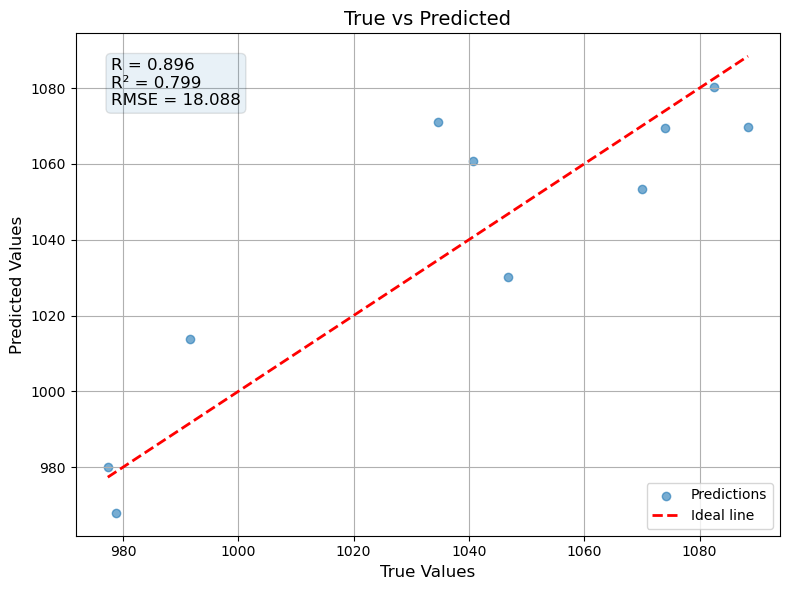

In [841]:
y_model = X_test @ b
plot_true_vs_predicted(y_test, y_model, title="True vs Predicted", figsize=(8, 6))